# Regularization and Pre-training in Deep Networks

In [61]:
# Check for all needed packages
import time

import numpy
import matplotlib
import mnists
# In case of ImportError, install them to the running kernel with
# %pip install numpy matplotlib mnists
# or the the runtime container with:
# !pip install numpy matplotlib mnists
# (In case of the latter, remember to restart the kernel!)

# Tested in Python 3.14.3 with:
# numpy==2.4.3
# matplotlib==3.10.8
# mnists==0.4.1

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import time

np.random.seed(1234)

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams["figure.figsize"] = [16, 9]

### Handy utility functions

In [63]:
def append_ones(matrix: np.ndarray) -> np.ndarray:
    """
    Appends a column of ones to the right side of a 2D matrix.
    """
    return np.concatenate(
        (matrix, np.ones((matrix.shape[0], 1), dtype=np.float32)), axis=1
    )


def zeros(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of zeros with the given shape.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. zeros(3, 4) creates a (3, 4) array.
    """
    return np.zeros(shape=tuple(dims), dtype=np.float32)


def ones(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of ones with the given shape.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. ones(3, 4) creates a (3, 4) array.
    """
    return np.ones(shape=tuple(dims), dtype=np.float32)


def rand(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of random values sampled from a uniform [0, 1) distribution.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. rand(3, 4) creates a (3, 4) array.
    """
    return np.random.rand(*dims).astype(np.float32)


def chunks(seq: list, size: int) -> tuple[np.ndarray]:
    """
    Splits a sequence into consecutive chunks of a given size.

    The last chunk may be smaller than `size` if the sequence length
    is not evenly divisible.

    Args:
        seq:  The input sequence (e.g. list or other sliceable) to split.
        size: The maximum number of elements in each chunk.

    Returns:
        Successive sub-sequences of length `size` (or less for the final chunk).
    """
    return tuple([seq[pos : (pos + size)] for pos in range(0, len(seq), size)])


def as_matrix(vector: np.ndarray) -> np.ndarray:
    """Reshape 1D vector to column matrix."""
    return np.reshape(vector, (-1, 1))


def one_hot_encode(labels: np.ndarray) -> np.ndarray:
    """Convert integer labels to one-hot encoded matrix."""
    (n_samples,) = labels.shape
    n_classes = np.max(labels) + 1

    one_hot = np.zeros((n_samples, n_classes), dtype=np.float32)
    one_hot[np.arange(n_samples), labels] = 1
    return one_hot


def arrange_tiles_img(examples: np.ndarray) -> np.ndarray:
    """
    Arrange 2D matrices as tiles

    Takes 4D `examples` tensor with dims:
        rows x cols x tile_height x tile_width
    """
    rows_count = examples.shape[0]
    cols_count = examples.shape[1]
    tile_height = examples.shape[2]
    tile_width = examples.shape[3]

    space_between_tiles = 2
    img_matrix = np.empty(
        shape=(
            rows_count * (tile_height + space_between_tiles) - space_between_tiles,
            cols_count * (tile_width + space_between_tiles) - space_between_tiles,
        )
    )
    img_matrix.fill(np.nan)

    for r in range(rows_count):
        for c in range(cols_count):
            x_0 = r * (tile_height + space_between_tiles)
            y_0 = c * (tile_width + space_between_tiles)
            img_matrix[x_0 : x_0 + tile_height, y_0 : y_0 + tile_width] = examples[r, c]

    return img_matrix


def preview_tiles(examples: np.ndarray) -> np.ndarray:
    """Previews the arrange tiles"""
    img = arrange_tiles_img(examples)
    plt.matshow(img, cmap="gray", interpolation="none")
    plt.axis("off")
    plt.show()

### Activation functions

In [64]:
def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))


def sigmoid_derivative(x: np.ndarray) -> np.ndarray:
    s = sigmoid(x)
    return s * (1.0 - s)

# MNIST dataset

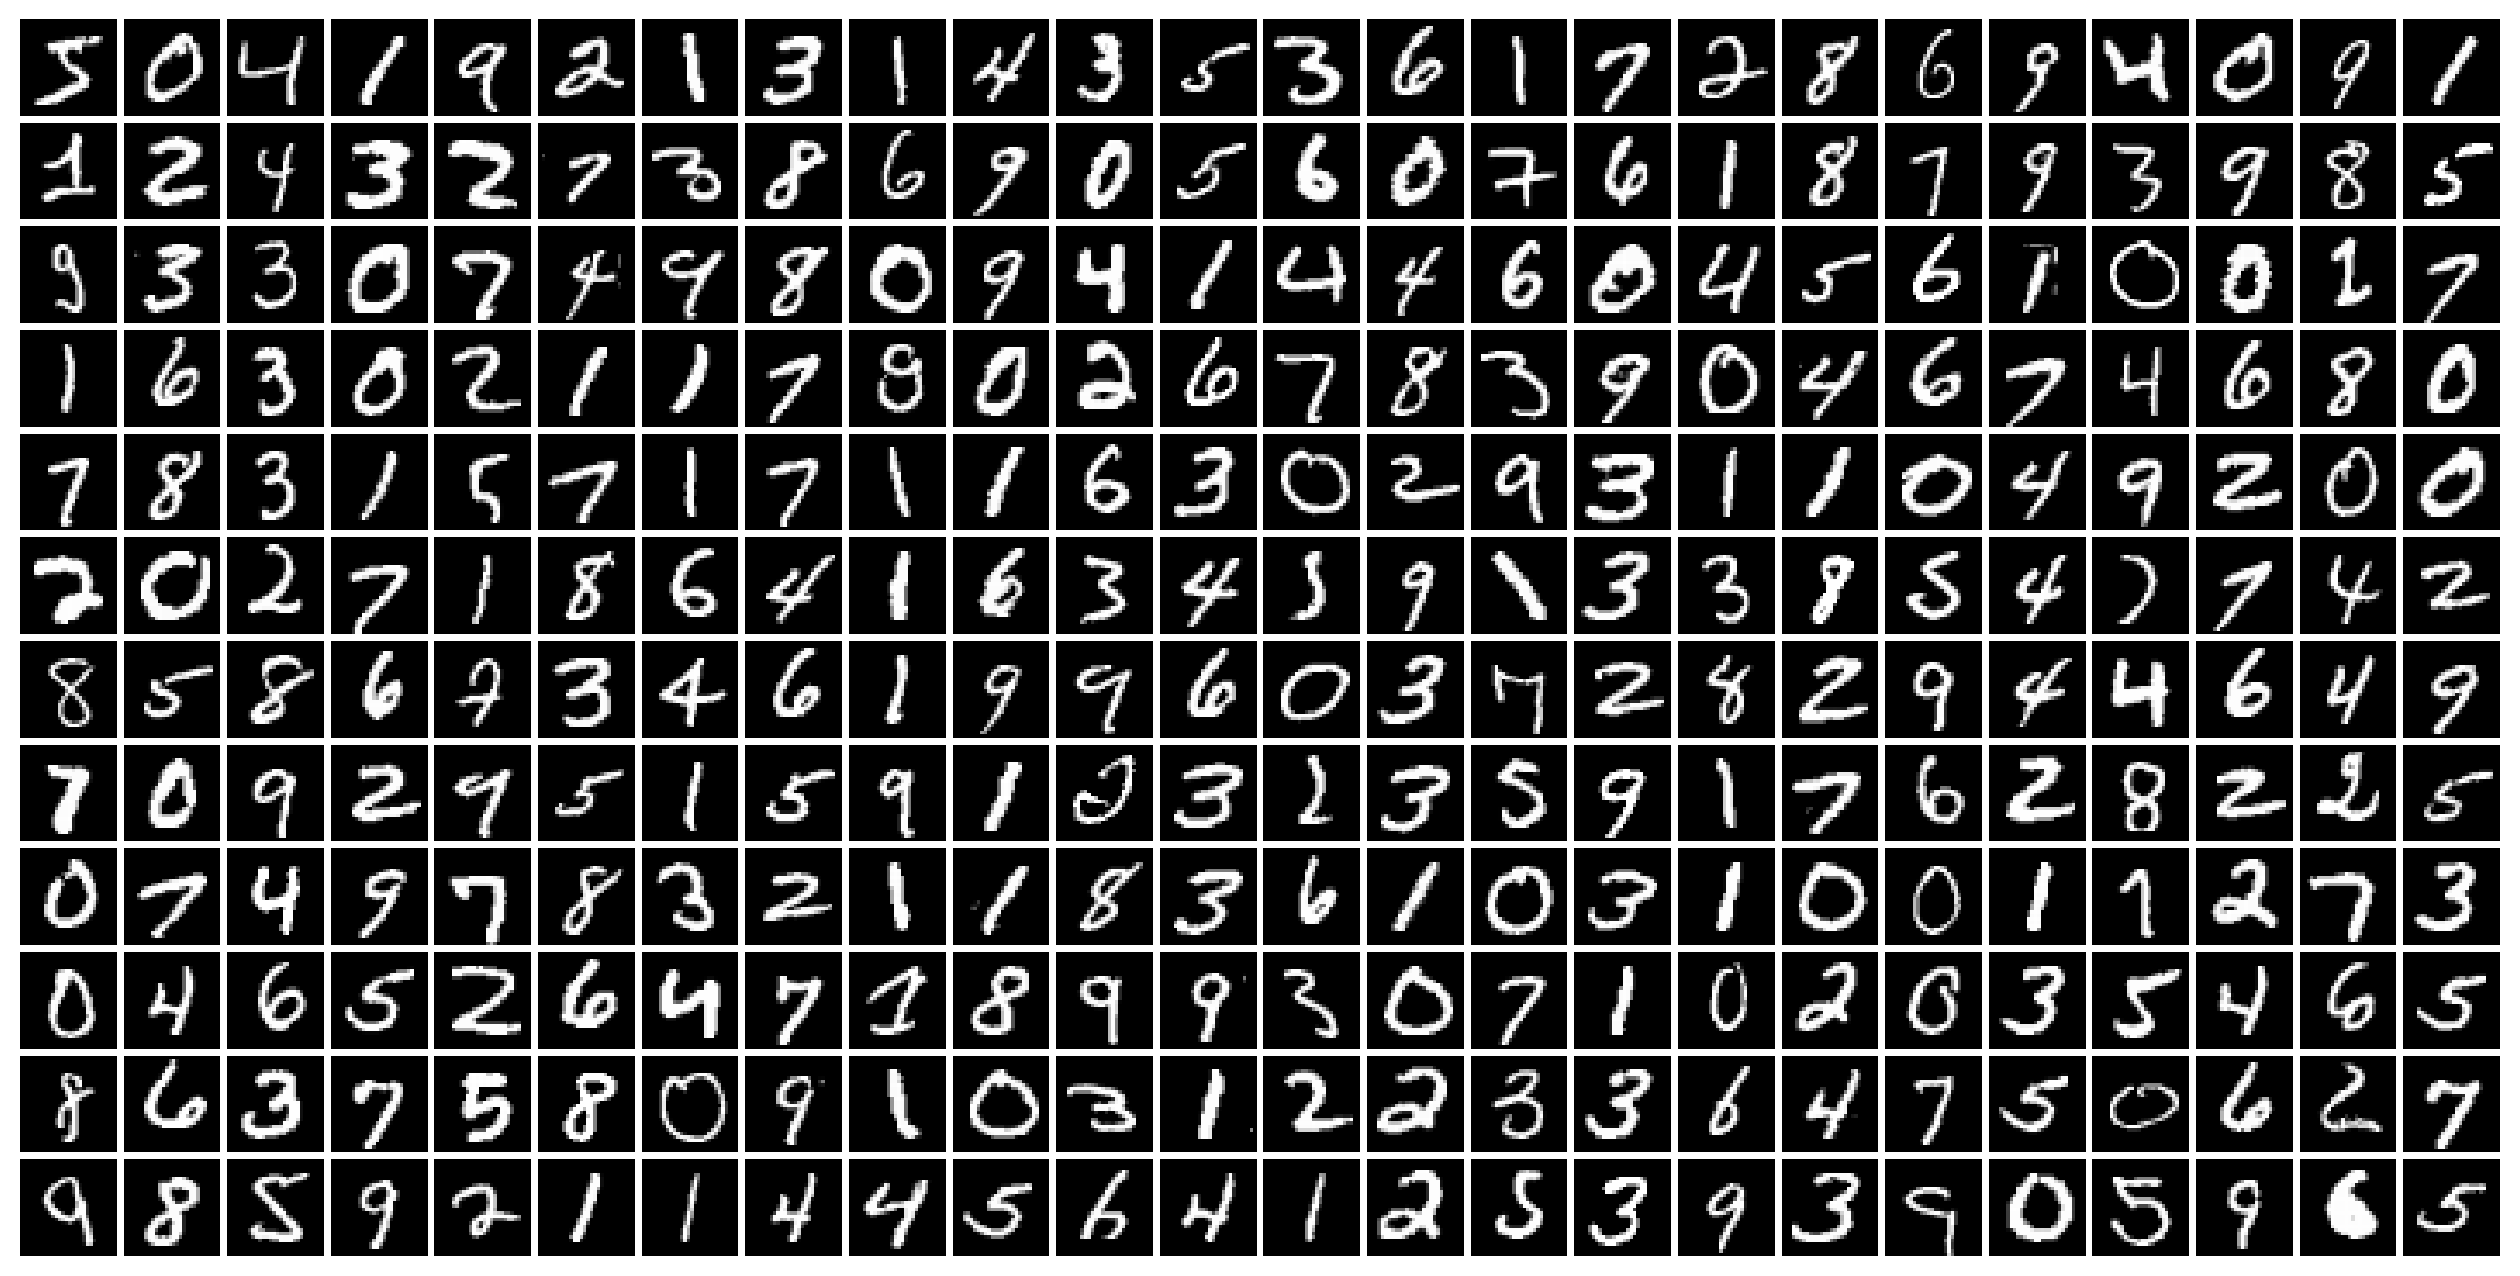

In [65]:
from mnists import MNIST

mnist = MNIST()

PREVIEW_N_ROWS = 12
PREVIEW_N_COLS = 24
TILE_DIM = 28  # [px]


def create_mnist_digits(n_rows: int, n_cols: int, tile_dim: int) -> np.ndarray:
    shape = (n_rows, n_cols, tile_dim, tile_dim)
    return np.reshape(mnist.train_images()[: 12 * 24], shape=shape)


mnist_digits = create_mnist_digits(PREVIEW_N_ROWS, PREVIEW_N_COLS, TILE_DIM)

preview_tiles(mnist_digits)

# Part 1: $L^1$ and $L^2$ penalties

In [66]:
class RestrictedBoltzmannMachine:
    """
    A Restricted Boltzmann Machine (RBM) with a single visible and hidden layer.

    The weight matrix W has shape (visible_size + 1, hidden_size + 1), where
    the extra row and column are reserved for bias units.

    Attributes:
        visible_size:  Number of visible (input) units, excluding the bias.
        hidden_size:   Number of hidden units, excluding the bias.
        learning_rate: Step size used during contrastive divergence updates.
        W:             Weight matrix of shape (visible_size+1, hidden_size+1).
        momentum:      Momentum coefficient
        l1_penalty:    Coefficent for the L1 regularization.
        l2_penalty:    Coefficent for the L2 regularization.
    """

    def __init__(
        self,
        visible_size: int,
        hidden_size: int,
        learning_rate: float,
        momentum: float = 0.0,
        l1_penalty: float = 0.0,
        l2_penalty: float = 0.0,
    ):
        self.visible_size = visible_size
        self.hidden_size = hidden_size
        self.learning_rate = learning_rate
        self.momentum = momentum

        self.l1_penalty = l1_penalty
        self.l2_penalty = l2_penalty

        self.reset()

    def reset(self):
        self.W = np.random.normal(
            scale=0.01,
            size=(self.visible_size + 1, self.hidden_size + 1),
        ).astype(np.float32)
        self.W[:, -1] = 0.0  # zero hidden-bias weights
        self.W[-1, :] = 0.0  # zero visible-bias weights
        self.M = zeros(self.visible_size + 1, self.hidden_size + 1)

In [67]:
def reconstruction_error(
    rbm: RestrictedBoltzmannMachine, minibatch: np.ndarray
) -> float:
    """
    Computes the mean per-sample reconstruction error on a minibatch.
    """

    observations_count = minibatch.shape[0]
    visible = append_ones(zeros(observations_count, rbm.visible_size))
    hidden = append_ones(zeros(observations_count, rbm.hidden_size))

    hidden[:, :-1] = sigmoid(minibatch @ rbm.W[:, :-1])
    visible[:, :-1] = sigmoid(hidden @ np.transpose(rbm.W[:-1, :]))
    return np.mean((minibatch[:, :-1] - visible[:, :-1]) ** 2)


### CDK with regulatization

Implement the Contrastive Divergence algorithm with $L^1$ and $L^2$ penalties. If
```python
rbm.l1_penalty > 0
```
the algorithm should constrain the weights with $L^1$ penalty. Otherwise, if
```python
rbm.l2_penalty > 0
```
the algorithm should constrain the weights with $L^2$ penalty.

Do **not** apply the penalties to the biases!

In [68]:
# The proper definition of the cdk()
def cdk(rbm: RestrictedBoltzmannMachine, minibatch: np.ndarray, k: int = 1) -> None:
    observations_count = minibatch.shape[0]

    positive_visible = minibatch
    negative_visible = append_ones(zeros(observations_count, rbm.visible_size))

    positive_hidden = append_ones(zeros(observations_count, rbm.hidden_size))
    negative_hidden = append_ones(zeros(observations_count, rbm.hidden_size))

    positive_hidden[:, :-1] = sigmoid(minibatch @ rbm.W[:, :-1])
    negative_hidden[:, :-1] = (positive_hidden[:, :-1] > rand(observations_count, rbm.hidden_size)).astype(np.float32)

    for cd_i in range(k):
        negative_visible[:, :-1] = sigmoid(negative_hidden @ np.transpose(rbm.W[:-1, :]))
        negative_visible[:, :-1] = (negative_visible[:, :-1] > rand(observations_count, rbm.visible_size)).astype(np.float32)

        negative_hidden[:, :-1] = sigmoid(negative_visible @ rbm.W[:, :-1])
        if cd_i < (k - 1):
            negative_hidden[:, :-1] = (negative_hidden[:, :-1] > rand(observations_count, rbm.hidden_size)).astype(np.float32)
    #

    gradient = (np.transpose(positive_visible) @ positive_hidden) - (np.transpose(negative_visible) @ negative_hidden)
    rbm.M = rbm.momentum * rbm.M + (rbm.learning_rate / observations_count) * gradient
    rbm.W += rbm.M

    if rbm.l1_penalty > 0:
        rbm.W[:-1, :-1] -= rbm.learning_rate * rbm.l1_penalty * np.sign(rbm.W[:-1, :-1])
    elif rbm.l2_penalty > 0:
        rbm.W[:-1, :-1] -= rbm.learning_rate * rbm.l2_penalty * rbm.W[:-1, :-1]
#

In [69]:
def train_epoch(
    rbm: RestrictedBoltzmannMachine, dataset: np.ndarray, batch_size: int
) -> None:
    batches_limit = dataset.shape[0] / batch_size
    for batch_idx, batch in enumerate(chunks(dataset, batch_size)):
        cdk(rbm, batch)
        if batch_idx % round(batches_limit / 50) == 0:
            print("#", end="")


def run_training(
    rbm: RestrictedBoltzmannMachine,
    dataset: np.ndarray,
    monitoring_set: np.ndarray,
    batch_size: int,
    epochs_count: int,
) -> None:
    for epoch in range(epochs_count):
        print(f"Epoch {epoch}:", end="\t")

        if epoch == 5:
            rbm.momentum = 0.8

        start_time = time.time()
        train_epoch(rbm, dataset, batch_size)
        elapsed = time.time() - start_time

        error = reconstruction_error(rbm, monitoring_set)
        print(
            "\telapsed: {0:>2.2f}s, reconstruction error: {1:>2.2f}".format(
                elapsed, error
            )
        )

    print("Training finished!")


def draw_filters(rbm: RestrictedBoltzmannMachine) -> None:
    """
    Visualises the learned RBM weight filters as a grid of 28x28 tiles.
    """

    filters: np.ndarray = np.reshape(
        np.transpose(rbm.W)[:-1, :-1],
        shape=(8, -1, TILE_DIM, TILE_DIM),
    )
    filters = np.clip(filters, -1, 1)
    preview_tiles(filters)

## Comparison of regularization penalties

In [70]:
DATASET_SIZE: int = 20000  # 60000 for whole dataset
DIGIT_SIZE: int = 28

VISIBLE_LAYER_SIZE: int = DIGIT_SIZE * DIGIT_SIZE
HIDDEN_LAYER_SIZE: int = 128

mnist_train = mnist.train_images().astype(np.float32) / 255.0
np.random.shuffle(mnist_train)
dataset = np.reshape(
    mnist_train[:DATASET_SIZE], shape=(DATASET_SIZE, DIGIT_SIZE * DIGIT_SIZE)
)
dataset = append_ones(dataset)

monitoring_indeces = np.random.choice(DATASET_SIZE, 256, replace=False)
monitoring_set = dataset[monitoring_indeces]

In [71]:
BATCH_SIZE: int = 128
EPOCHS_COUNT: int = 50

LEARNING_RATE: float = 0.1
MOMENTUM: float = 0.5

### RBM with no regularization

In [72]:
L1_PENALTY: float = 0.0
L2_PENALTY: float = 0.0

np.random.seed(1234)
rbm_plain = RestrictedBoltzmannMachine(
    visible_size=VISIBLE_LAYER_SIZE,
    hidden_size=HIDDEN_LAYER_SIZE,
    learning_rate=LEARNING_RATE,
    momentum=MOMENTUM,
    l1_penalty=L1_PENALTY,
    l2_penalty=L2_PENALTY,
)

run_training(
    rbm=rbm_plain,
    dataset=dataset,
    monitoring_set=monitoring_set,
    batch_size=BATCH_SIZE,
    epochs_count=EPOCHS_COUNT,
)

Epoch 0:	#####################################################	elapsed: 1.21s, reconstruction error: 0.03
Epoch 1:	#####################################################	elapsed: 1.58s, reconstruction error: 0.02
Epoch 2:	#####################################################	elapsed: 1.51s, reconstruction error: 0.02
Epoch 3:	#####################################################	elapsed: 1.35s, reconstruction error: 0.02
Epoch 4:	#####################################################	elapsed: 1.46s, reconstruction error: 0.02
Epoch 5:	#####################################################	elapsed: 1.44s, reconstruction error: 0.02
Epoch 6:	#####################################################	elapsed: 1.45s, reconstruction error: 0.01
Epoch 7:	#####################################################	elapsed: 1.53s, reconstruction error: 0.01
Epoch 8:	#####################################################	elapsed: 1.32s, reconstruction error: 0.01
Epoch 9:	#####################################

### RBM with $L^1$ penalty

In [73]:
L1_PENALTY: float = 0.0001
L2_PENALTY: float = 0.0

np.random.seed(1234)
rbm_l1 = RestrictedBoltzmannMachine(
    visible_size=VISIBLE_LAYER_SIZE,
    hidden_size=HIDDEN_LAYER_SIZE,
    learning_rate=LEARNING_RATE,
    momentum=MOMENTUM,
    l1_penalty=L1_PENALTY,
    l2_penalty=L2_PENALTY,
)

run_training(
    rbm=rbm_l1,
    dataset=dataset,
    monitoring_set=monitoring_set,
    batch_size=BATCH_SIZE,
    epochs_count=EPOCHS_COUNT,
)

Epoch 0:	#####################################################	elapsed: 3.38s, reconstruction error: 0.03
Epoch 1:	#####################################################	elapsed: 2.88s, reconstruction error: 0.02
Epoch 2:	#####################################################	elapsed: 3.24s, reconstruction error: 0.02
Epoch 3:	#####################################################	elapsed: 2.69s, reconstruction error: 0.02
Epoch 4:	#####################################################	elapsed: 2.48s, reconstruction error: 0.02
Epoch 5:	#####################################################	elapsed: 2.39s, reconstruction error: 0.02
Epoch 6:	#####################################################	elapsed: 2.36s, reconstruction error: 0.01
Epoch 7:	#####################################################	elapsed: 3.19s, reconstruction error: 0.01
Epoch 8:	#####################################################	elapsed: 2.83s, reconstruction error: 0.01
Epoch 9:	#####################################

### RBM with $L^2$ penalty

In [74]:
L1_PENALTY: float = 0.0
L2_PENALTY: float = 0.0005

np.random.seed(1234)
rbm_l2 = RestrictedBoltzmannMachine(
    visible_size=VISIBLE_LAYER_SIZE,
    hidden_size=HIDDEN_LAYER_SIZE,
    learning_rate=LEARNING_RATE,
    momentum=MOMENTUM,
    l1_penalty=L1_PENALTY,
    l2_penalty=L2_PENALTY,
)

run_training(
    rbm=rbm_l2,
    dataset=dataset,
    monitoring_set=monitoring_set,
    batch_size=BATCH_SIZE,
    epochs_count=EPOCHS_COUNT,
)

Epoch 0:	#####################################################	elapsed: 0.93s, reconstruction error: 0.03
Epoch 1:	#####################################################	elapsed: 1.06s, reconstruction error: 0.02
Epoch 2:	#####################################################	elapsed: 0.79s, reconstruction error: 0.02
Epoch 3:	#####################################################	elapsed: 0.83s, reconstruction error: 0.02
Epoch 4:	#####################################################	elapsed: 0.66s, reconstruction error: 0.02
Epoch 5:	#####################################################	elapsed: 0.84s, reconstruction error: 0.02
Epoch 6:	#####################################################	elapsed: 0.69s, reconstruction error: 0.01
Epoch 7:	#####################################################	elapsed: 0.67s, reconstruction error: 0.01
Epoch 8:	#####################################################	elapsed: 0.98s, reconstruction error: 0.01
Epoch 9:	#####################################

### Plain filters

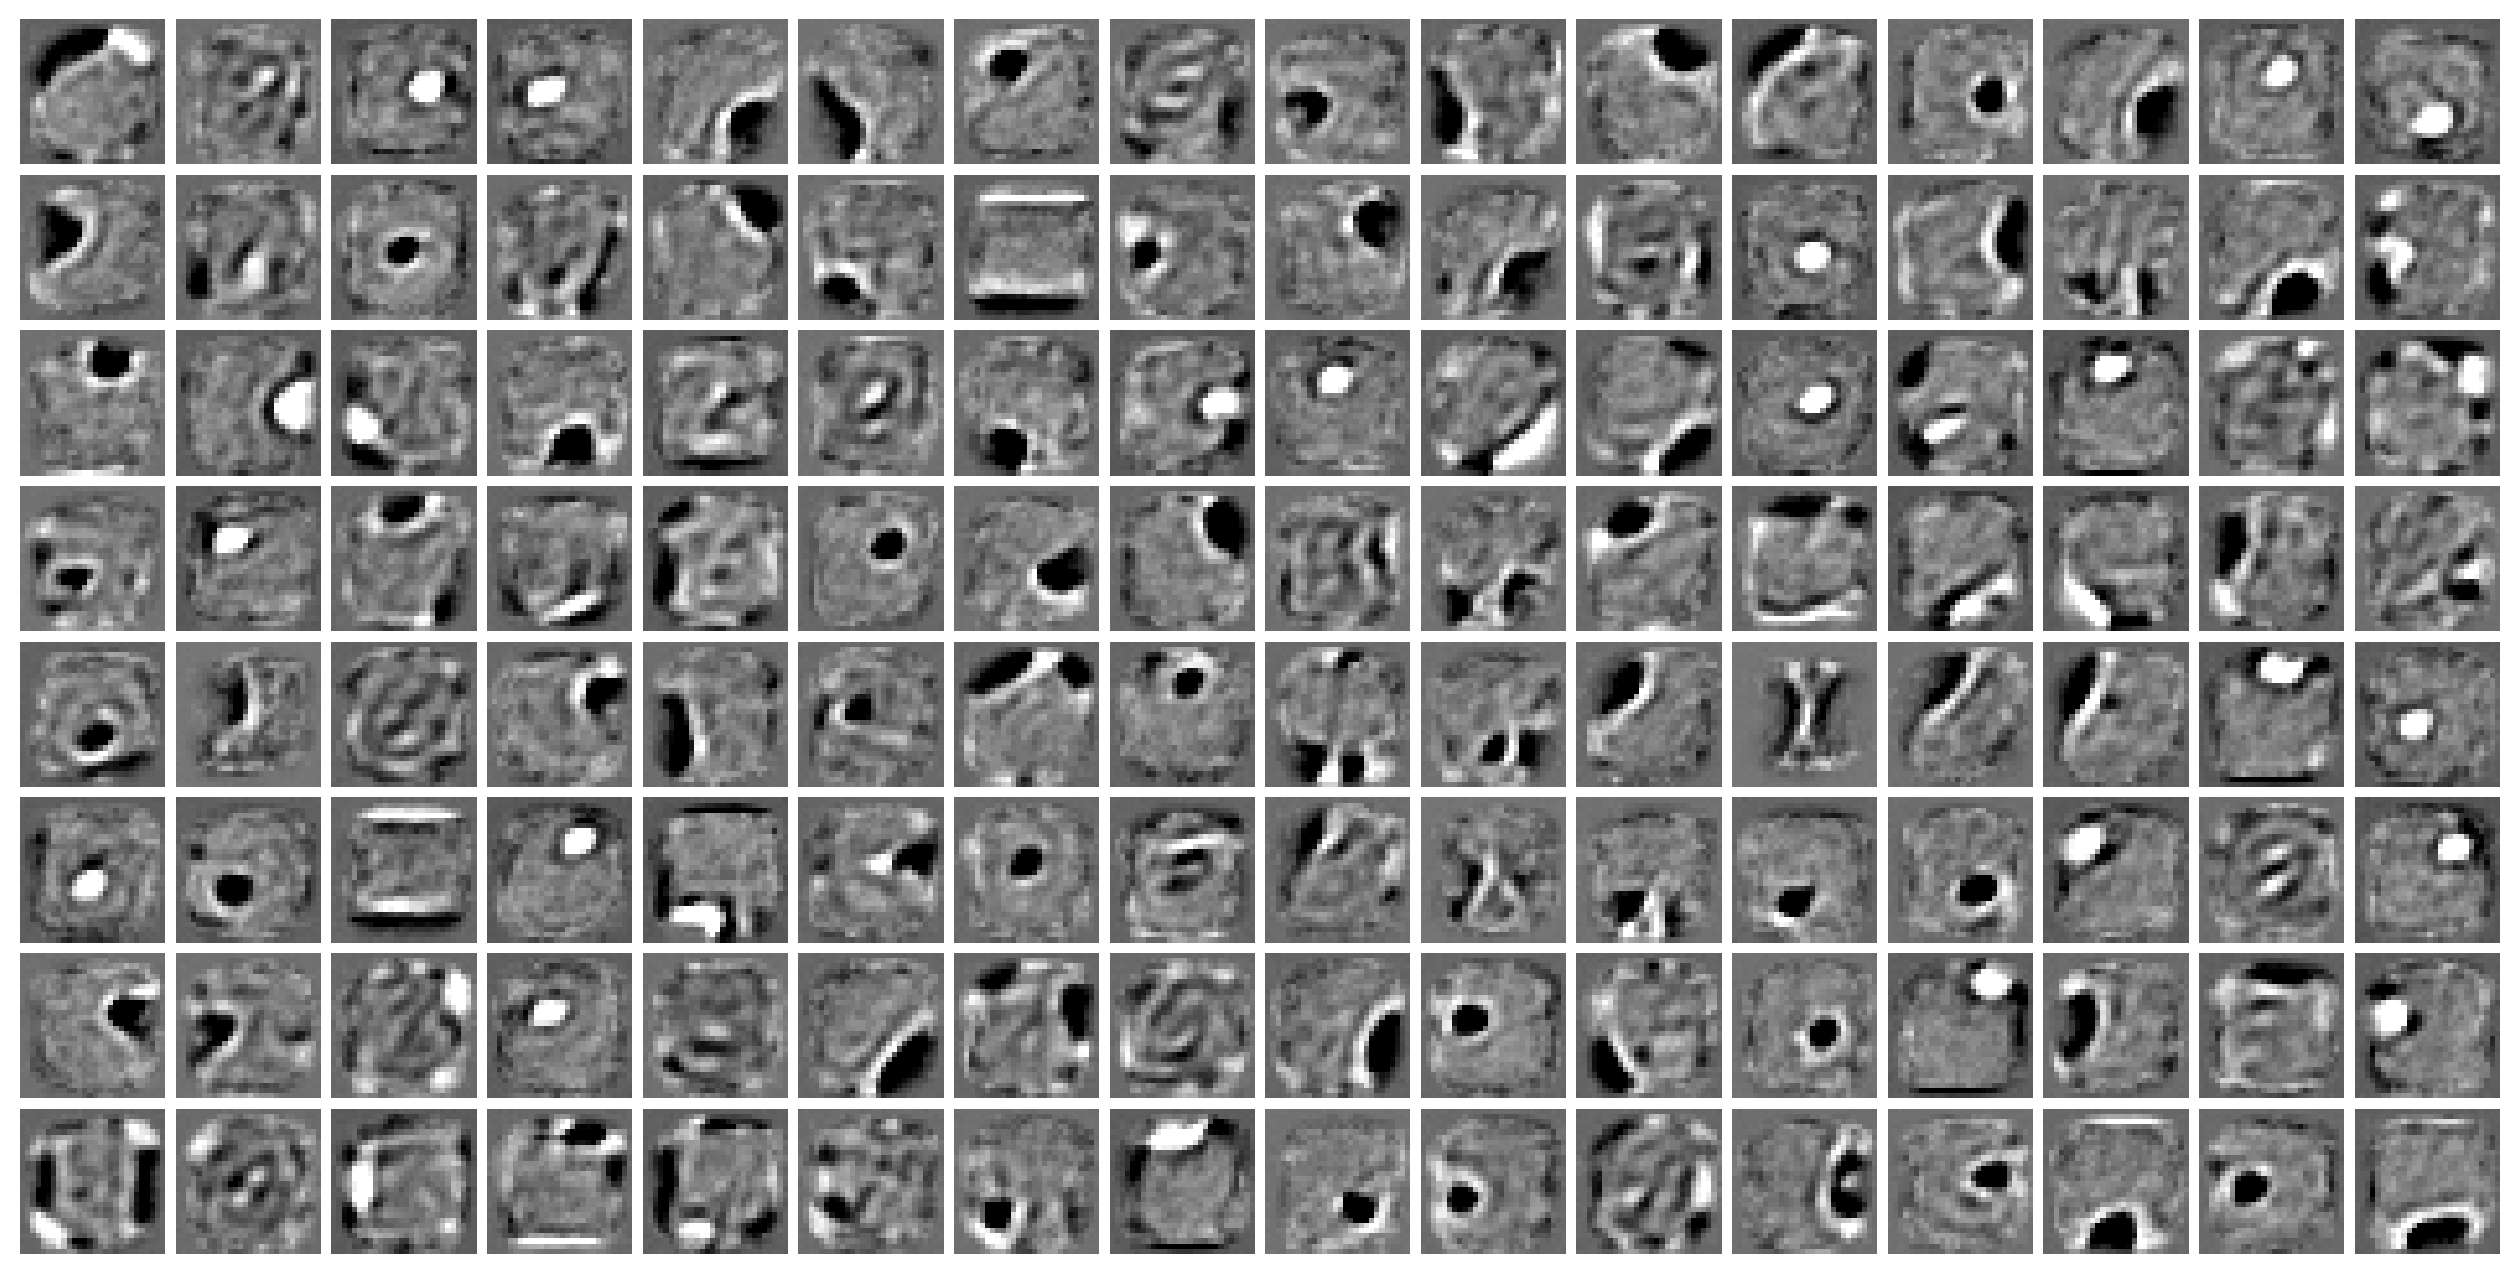

In [75]:
draw_filters(rbm_plain)

### $L^1$ filters

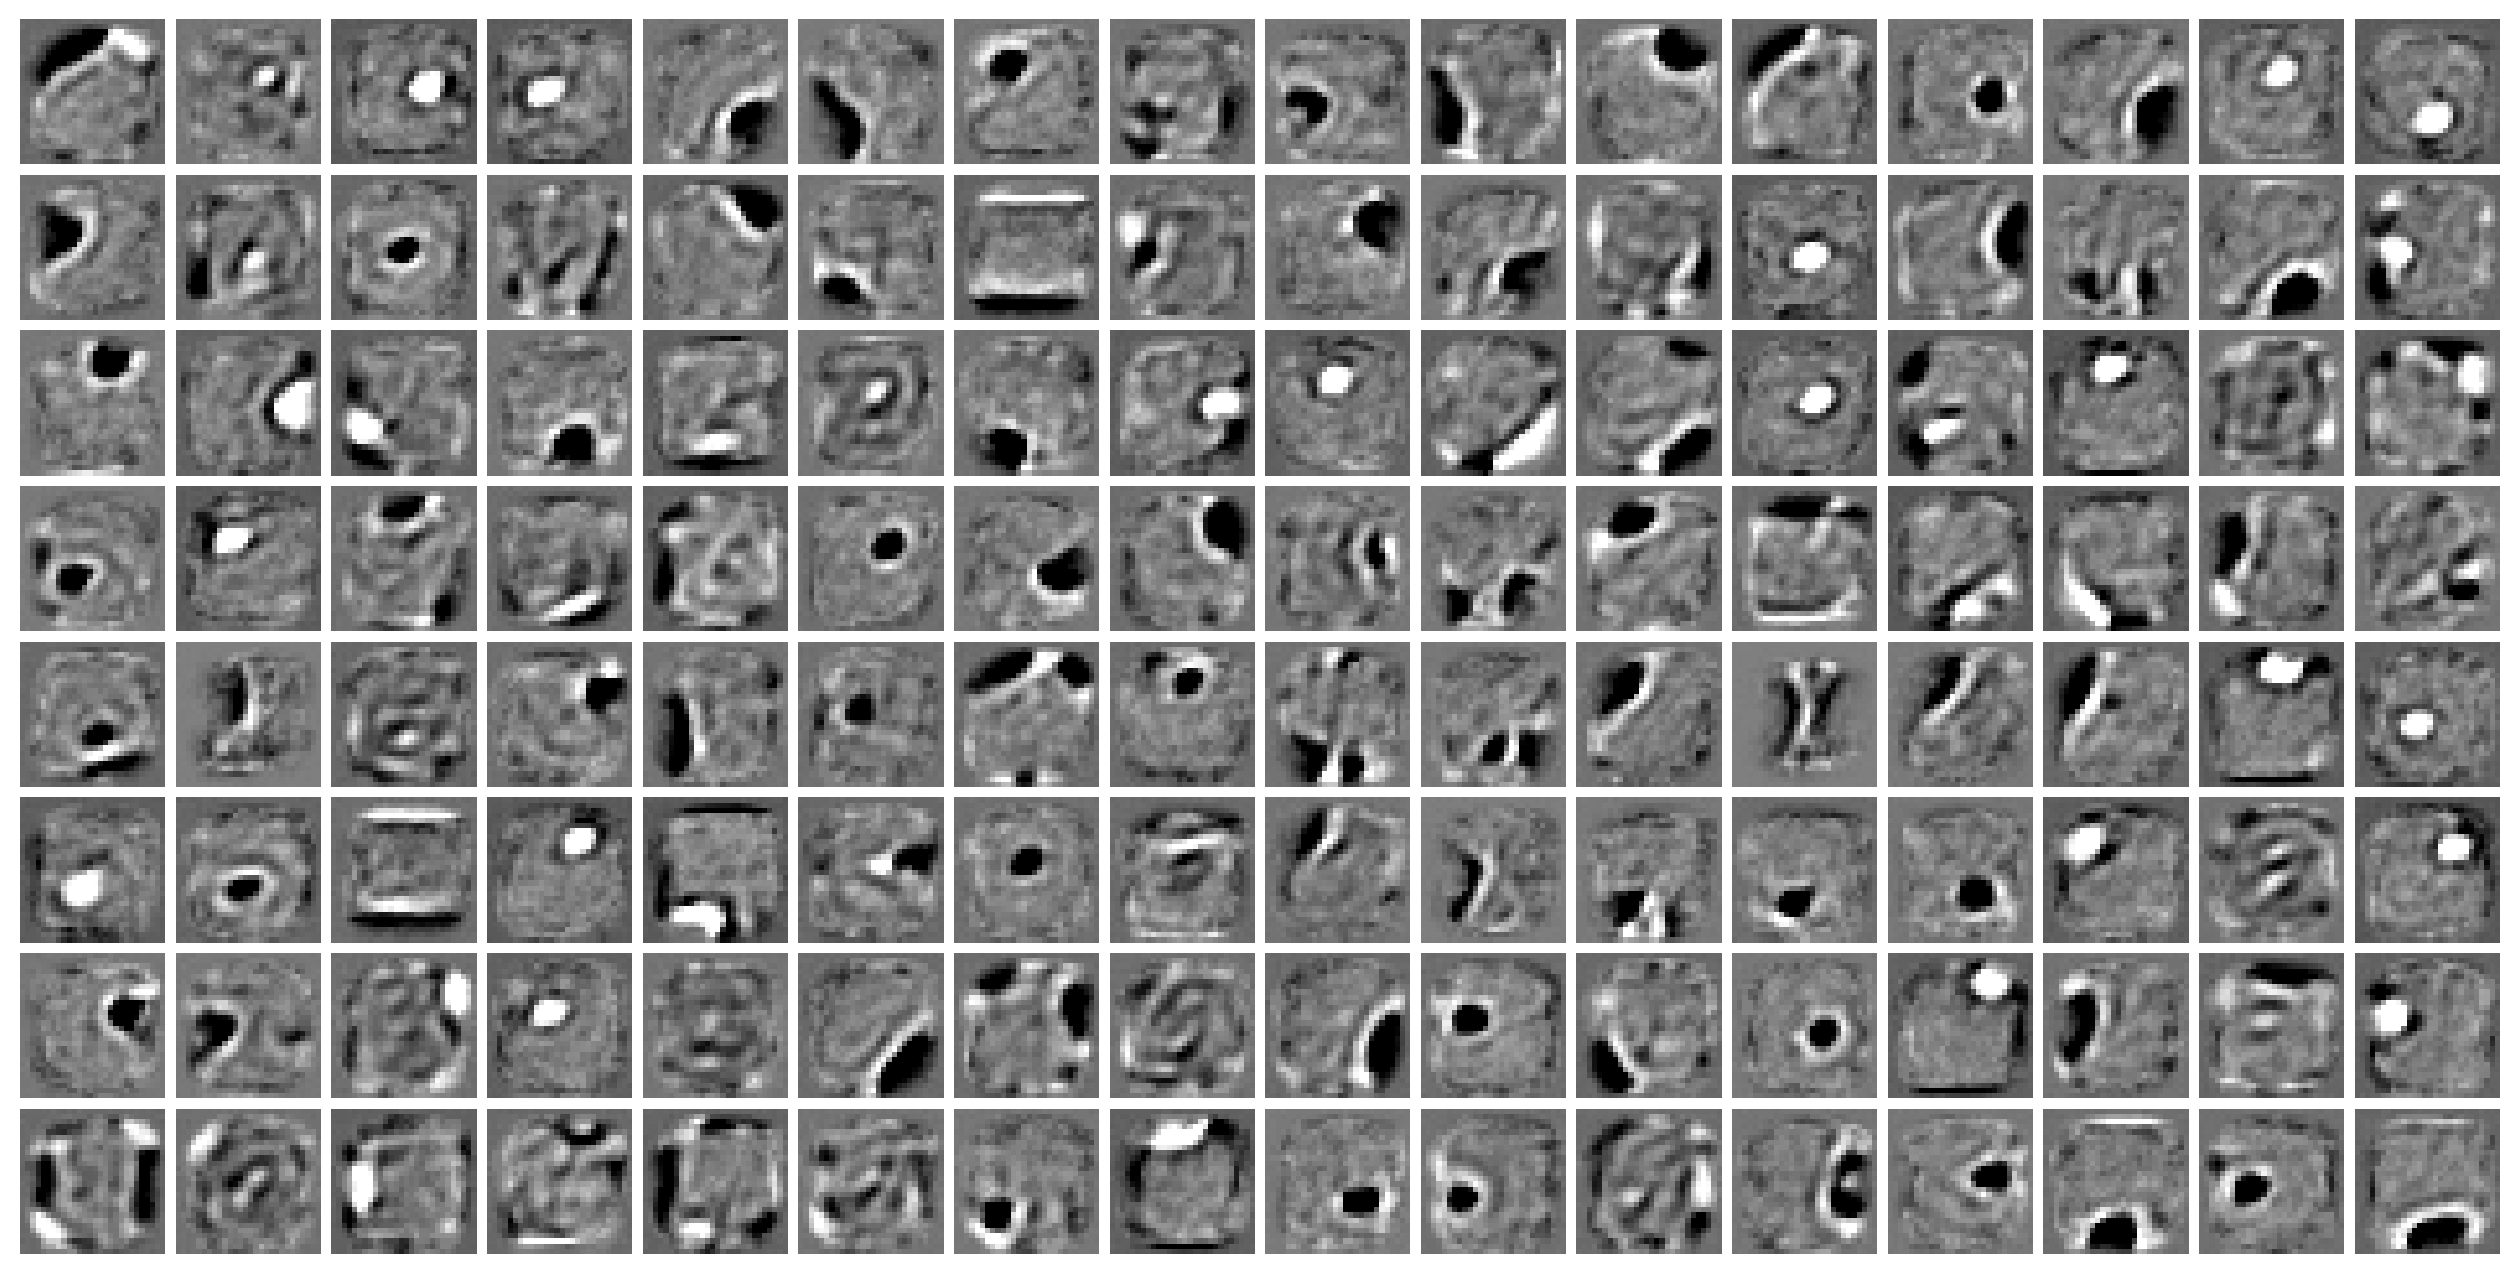

In [76]:
draw_filters(rbm_l1)

### $L^2$ filters

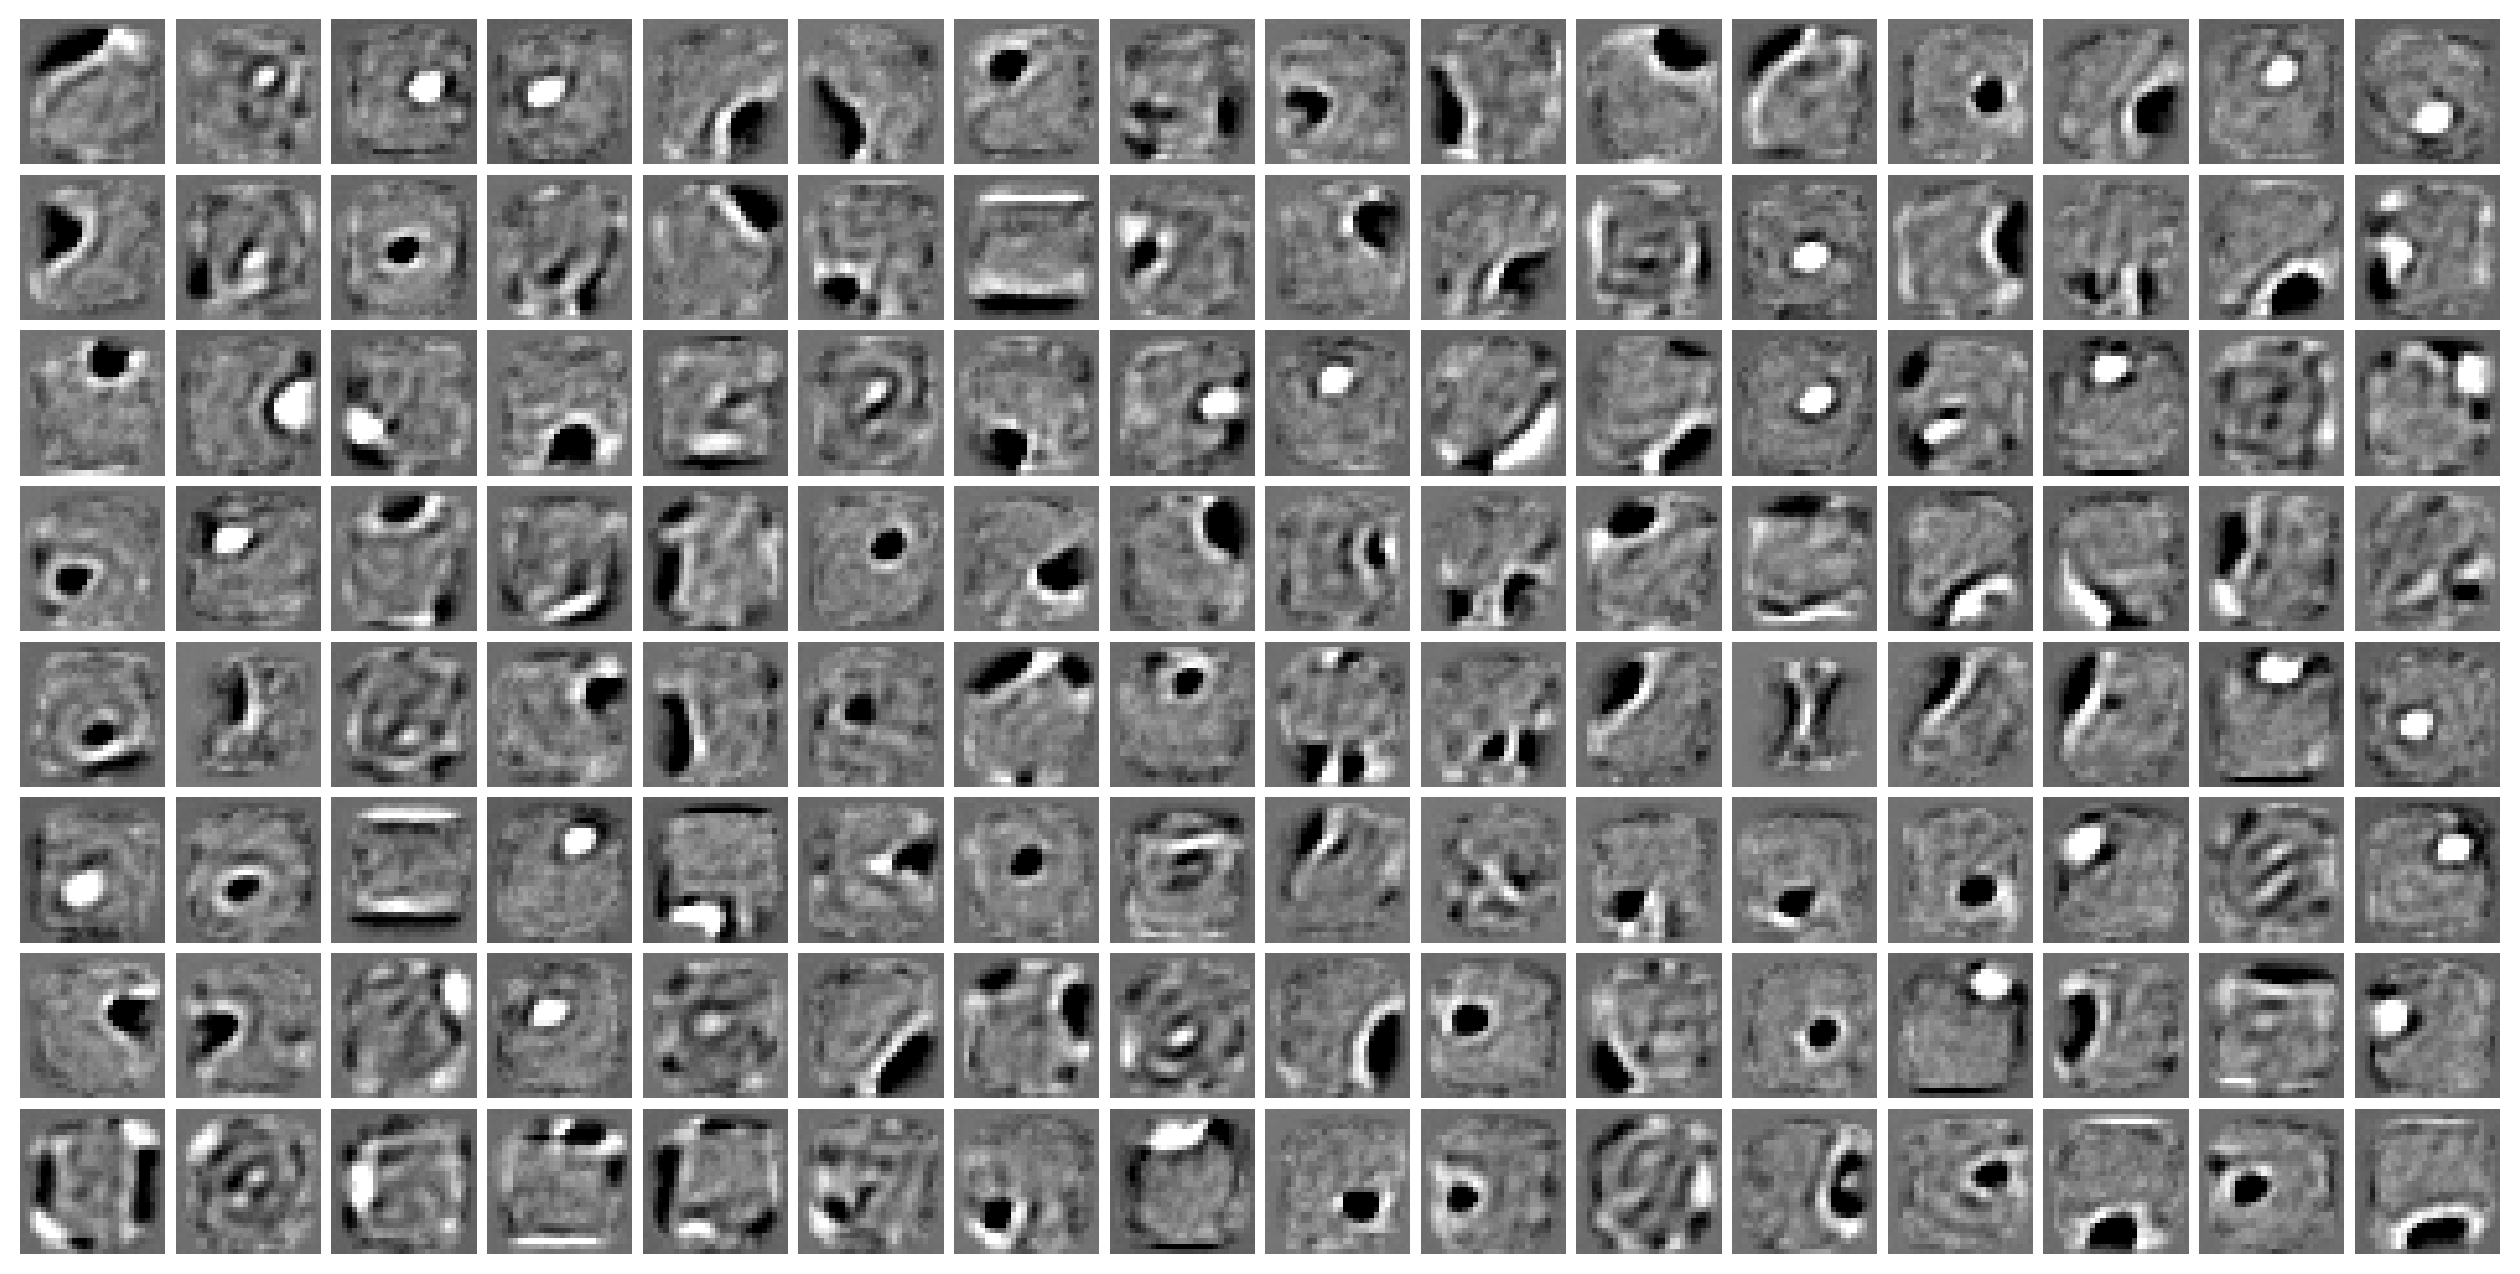

In [77]:
draw_filters(rbm_l2)

# Part 2: MLP pretraining

In [78]:
def softmax(x: np.ndarray) -> np.ndarray:
    max_z = np.max(x, axis=1, keepdims=True)
    x = x - max_z
    exp_x = np.exp(x)

    sum_z = np.sum(exp_x, axis=1, keepdims=True)
    return exp_x / sum_z
#

In [79]:
class Layer:
    def __init__(
        self,
        visible_size: int,
        hidden_size: int,
        activation_fun,
        d_activation_fun,
        learning_rate: float,
        momentum: float,
        l2_penalty: float,
    ):
        self.visible_size = visible_size
        self.hidden_size = hidden_size

        self.activation_fun = activation_fun
        self.d_activation_fun = d_activation_fun

        self.learning_rate = learning_rate
        self.momentum = momentum

        self.l2_penalty = l2_penalty

        self.reset()

    def reset(self):
        self.W = np.random.normal(
            scale=0.01, size=(self.visible_size + 1, self.hidden_size)
        ).astype(np.float32)
        self.W[-1, :] = 0.0

        self.activations = None
        self.d_activations = None
        self.deltas = None

        self.M = zeros(self.visible_size + 1, self.hidden_size)

In [80]:
from typing import TypeAlias

MLP: TypeAlias = list[Layer]

### Forward pass

In [81]:
def forward_pass(mlp: MLP, batch: np.ndarray, compute_derivatives: bool) -> np.ndarray:
    visible = batch

    for layer_idx, layer in enumerate(mlp):
        z = visible @ layer.W
        layer.activations = layer.activation_fun(z)

        if compute_derivatives and (layer_idx < len(mlp) - 1):
            layer.d_activations = layer.d_activation_fun(z)

        visible = layer.activations
        visible = append_ones(visible)

    return visible[:, :-1]
#

### Error backpropagation

Extend the implementation of error backpropagation (from Lab 6) with $L^2$ penalty. Apply the penalty when:
```python
rbm.l2_penalty > 0
```

Do **not** apply the penalty to the biases.

In [82]:
def error_backpropagate(mlp: MLP, batch: np.ndarray) -> None:
    observations_count = batch.shape[0]

    for layer_idx, layer in reversed(list(enumerate(mlp))):
        if layer_idx > 0:
            prev_layer = mlp[layer_idx - 1]
            visible = append_ones(prev_layer.activations)

            error = layer.deltas @ layer.W[:-1, :].T
            prev_layer.deltas = error * prev_layer.d_activations
        else:
            visible = batch

        gradient = visible.T @ layer.deltas / observations_count
        layer.M = layer.momentum * layer.M + layer.learning_rate * gradient

        if layer.l2_penalty > 0:
            layer.M[:-1] += layer.learning_rate * layer.l2_penalty * layer.W[:-1]
        layer.W -= layer.M
#

### MLP training

In [83]:
def train_mlp(
    mlp: MLP, dataset: np.ndarray, labels: np.ndarray, batch_size: np.ndarray
) -> None:
    batches_limit = dataset.shape[0] / batch_size

    batched_data = chunks(dataset, batch_size)
    batched_labels = chunks(labels, batch_size)

    for batch_idx, (batch, batch_labels) in enumerate(
        zip(batched_data, batched_labels)
    ):
        # Forward pass: compute activatations and derivatives of activations
        y = forward_pass(mlp, batch, True)

        # implement the deltas for the last layer (i.e. the loss function)
        mlp[-1].deltas = y - batch_labels

        error_backpropagate(mlp, batch)

        if batch_idx % round(batches_limit / 50) == 0:
            print("#", end="")

In [84]:
def classify(mlp, batch):
    probabilities = forward_pass(mlp, batch, False)
    return np.argmax(probabilities, axis=1)


def run_mlp_training(
    mlp: MLP,
    train_set: np.ndarray,
    train_labels: np.ndarray,
    validation_set: np.ndarray,
    validation_labels: np.ndarray,
    batch_size: int,
    epochs_count: int,
) -> None:

    for epoch in range(epochs_count):
        print(f"Epoch {epoch + 1}:", end="\t")

        start_time = time.time()
        train_mlp(mlp, train_set, train_labels, batch_size)
        elapsed = time.time() - start_time

        predictions = classify(mlp, validation_set)
        accuracy = (
            100.0 * np.sum(predictions == validation_labels) / predictions.shape[0]
        )
        print(f"\telapsed: {elapsed:>2.2f}s, accuracy: {accuracy:>2.2f}")

    print("Training finished!")


def draw_layer_filters(layer: Layer) -> None:
    filters = np.reshape(layer.W[:-1, :].T, shape=(8, -1, 28, 28))
    preview_tiles(filters)

## DBN Pretraining

In [85]:
DBN: TypeAlias = list[RestrictedBoltzmannMachine]

In [86]:
def propagate_up(
    dbn: DBN,
    layers_count: int,
    visible: np.ndarray,
) -> np.ndarray:
    """
    Forward pass through DBN layers: propagates visible units upward to the target layer.
    Appends bias term (ones) and applies sigmoid activation after matrix multiplication.
    """
    for i in range(layers_count):
        visible = append_ones(sigmoid(visible @ dbn[i].W[:, :-1]))
    return visible


def propagate_down(
    dbn: DBN,
    layers_count: int,
    hidden: np.ndarray,
) -> np.ndarray:
    """
    Reconstruct data by propagating downward through the DBN.
    Appends bias term (ones) and applies sigmoid activation after matrix multiplication.
    """
    for i in reversed(range(layers_count)):
        hidden = append_ones(sigmoid(hidden @ np.transpose(dbn[i].W[:-1, :])))
    return hidden

In [87]:
def dbn_reconstruction_error(
    dbn: DBN,
    layer_idx: int,
    minibatch: np.ndarray,
) -> float:
    """
    Compute the reconstruction error for a selected DBN layer.

    The minibatch is first propagated upward to the chosen layer,
    then the reconstruction error is evaluated for that RBM.
    """
    hidden = propagate_up(dbn, layer_idx, minibatch)
    visible = propagate_down(dbn, layer_idx, hidden)
    return np.mean((minibatch[:, :-1] - visible[:, :-1]) ** 2)

In [88]:
def train_dbn_layer(
    dbn: DBN,
    layer_idx: int,
    dataset: np.ndarray,
    batch_size: int,
) -> None:
    """
    Train one DBN layer using greedy layer-wise pretraining.

    The dataset is first propagated through all previously trained layers.
    Then the selected RBM layer is trained on minibatches.
    """
    dataset = propagate_up(dbn, layer_idx, dataset)

    batches_limit = dataset.shape[0] / batch_size
    for batch_idx, batch in enumerate(chunks(dataset, batch_size)):
        cdk(dbn[layer_idx], batch)
        if batch_idx % round(batches_limit / 50) == 0:
            print("#", end="")

In [89]:
def train_dbn(
    dbn: DBN,
    dataset: np.ndarray,
    monitoring_set: np.ndarray,
    batch_size: int,
    epochs_count: int,
) -> None:
    for layer_idx in range(len(dbn)):
        print(f"\nLearning layer {layer_idx}")

        for epoch in range(epochs_count):
            print(f"Epoch {epoch}:", end="\t")

            if epoch == 5:
                dbn[layer_idx].momentum = 0.8

            start_time = time.time()
            train_dbn_layer(dbn, layer_idx, dataset, batch_size)
            elapsed = time.time() - start_time

            error = dbn_reconstruction_error(dbn, layer_idx, monitoring_set)
            print(f"\telapsed: {elapsed:>2.2f}s, reconstruction error: {error:>2.2f}")

##  Initializing MLP with DBN weights

Implement initialization of MLP weights (and biases) using weights (and biases) from the DBN layers.

Make sure that the MLP weights (and biases) are **copies** of the DBN weights (and biases). You can use ```np.copy(...)``` function to copy the weights (simple assignment will make a view instead of a copy).

In [90]:
# Protip for better encpaulsation: create a helper class for MLP, with a custom constructor (@classmethod), `from_dbn(dbn: DBN)`
# However, there is no need for overengineering for this laboratories.

def initialize_mlp_from_dbn(mlp: MLP, dbn: DBN) -> None:
    for layer_idx in range(len(dbn)):
        mlp[layer_idx].W = np.copy(dbn[layer_idx].W[:, :-1])

# MNIST digits classification

In [91]:
np.random.seed(1234)

DATASET_SIZE: int = 10000  # 60000 for whole dataset
DIGIT_SIZE: int = 28

##### Train set #####

mnist_train_images = mnist.train_images().astype(np.float32) / 255.0
mnist_train_labels = mnist.train_labels()

order = np.random.permutation(len(mnist_train_images))
mnist_train_images = mnist_train_images[order]
mnist_train_labels = mnist_train_labels[order]

mnist_train_images = np.reshape(
    mnist_train_images[:DATASET_SIZE], shape=(DATASET_SIZE, DIGIT_SIZE * DIGIT_SIZE)
)
mnist_train_images = append_ones(mnist_train_images)

mnist_train_labels = mnist_train_labels[:DATASET_SIZE]
mnist_train_labels = one_hot_encode(mnist_train_labels)

monitoring_set_indeces = np.random.choice(
    mnist_train_images.shape[0], 512, replace=False
)
monitoring_set = mnist_train_images[monitoring_set_indeces]

##### Test set #####

mnist_test_images = mnist.test_images().astype(np.float32) / 255.0
mnist_test_images = np.reshape(mnist_test_images, shape=(-1, DIGIT_SIZE * DIGIT_SIZE))
mnist_test_images = append_ones(mnist_test_images)

mnist_test_labels = mnist.test_labels()

### Plain vs pretrained MLP comparison

In [92]:
from IPython.core.display import HTML


def compare_pretraining_results(
    mlp: MLP,
    dbn: DBN,
    train_set: np.ndarray,
    train_labels: np.ndarray,
    validation_set: np.ndarray,
    validation_labels: np.ndarray,
    monitoring_set: np.ndarray,
    batch_size: int,
    epochs_count: int,
) -> None:
    for layer in mlp:
        layer.reset()

    display(HTML("<h3>Plain MLP training</h3>"))
    run_mlp_training(
        mlp=mlp,
        train_set=train_set,
        train_labels=train_labels,
        validation_set=validation_set,
        validation_labels=validation_labels,
        batch_size=batch_size,
        epochs_count=epochs_count,
    )

    display(HTML("<h3>Input layer filters in the plain MLP</h3>"))
    draw_layer_filters(mlp[0])

    display(HTML("<h3>DBN training</h3>"))
    train_dbn(
        dbn=dbn,
        dataset=train_set,
        monitoring_set=monitoring_set,
        batch_size=batch_size,
        epochs_count=epochs_count,
    )

    for layer in mlp:
        layer.reset()

    initialize_mlp_from_dbn(mlp, dbn)

    display(HTML("<h3>Finetuning pretrained MLP</h3>"))
    run_mlp_training(
        mlp=mlp,
        train_set=train_set,
        train_labels=train_labels,
        validation_set=validation_set,
        validation_labels=validation_labels,
        batch_size=batch_size,
        epochs_count=epochs_count,
    )

    display(HTML("<h3>First layer filters in the DBN</h3>"))
    draw_filters(dbn[0])

    display(HTML("<h3>Input layer filters in the pretrained & finetuned MLP</h3>"))
    draw_layer_filters(mlp[0])

In [93]:
VISIBLE_LAYER_SIZE: int = DIGIT_SIZE * DIGIT_SIZE
HIDDEN_LAYER_SIZE: int = 256

BATCH_SIZE: int = 128
EPOCHS_COUNT: int = 50

LEARNING_RATE: float = 0.1
SOFTMAX_LEARNING_RATE: float = 0.15
MOMENTUM: float = 0.5
L2_PENALTY: float = 0.00002

### Shallow neural network

Epoch 1:	########################################	elapsed: 0.47s, accuracy: 8.92
Epoch 2:	########################################	elapsed: 0.45s, accuracy: 8.92
Epoch 3:	########################################	elapsed: 0.28s, accuracy: 8.92
Epoch 4:	########################################	elapsed: 0.21s, accuracy: 11.35
Epoch 5:	########################################	elapsed: 0.27s, accuracy: 11.35
Epoch 6:	########################################	elapsed: 0.28s, accuracy: 11.35
Epoch 7:	########################################	elapsed: 0.30s, accuracy: 11.35
Epoch 8:	########################################	elapsed: 0.25s, accuracy: 11.35
Epoch 9:	########################################	elapsed: 0.20s, accuracy: 11.35
Epoch 10:	########################################	elapsed: 0.21s, accuracy: 11.35
Epoch 11:	########################################	elapsed: 0.26s, accuracy: 11.35
Epoch 12:	########################################	elapsed: 0.35s, accuracy: 11.38
Epoch 13:	######

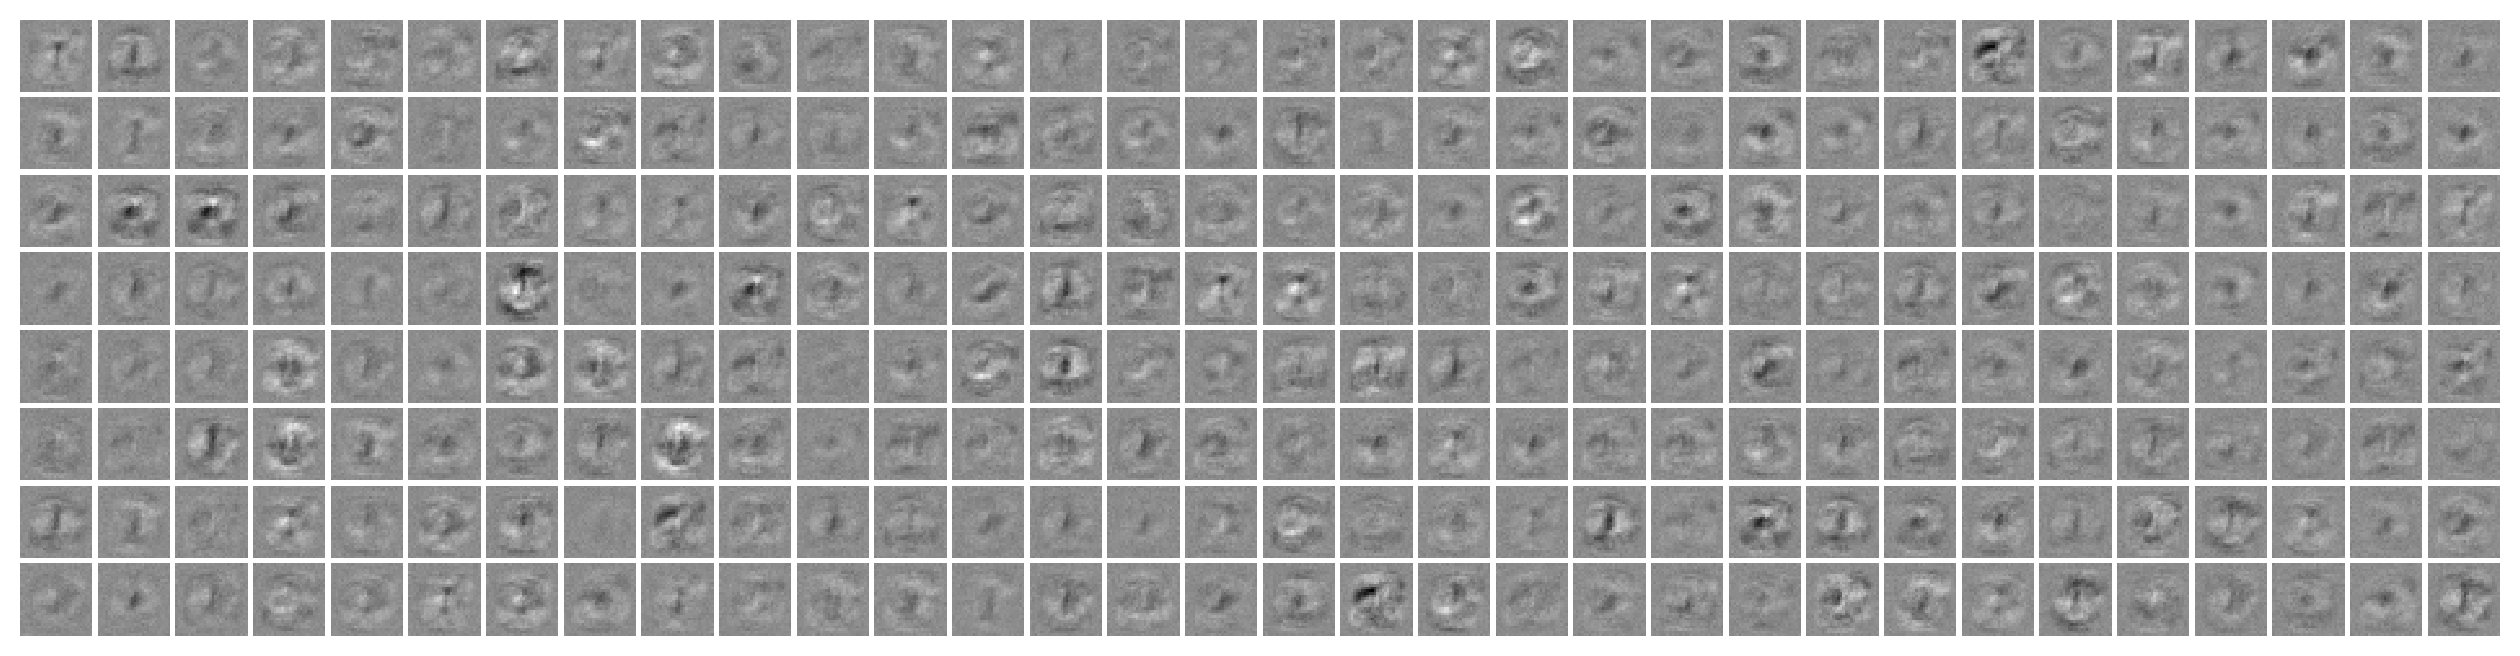


Learning layer 0
Epoch 0:	########################################	elapsed: 0.60s, reconstruction error: 0.00
Epoch 1:	########################################	elapsed: 0.57s, reconstruction error: 0.00
Epoch 2:	########################################	elapsed: 0.65s, reconstruction error: 0.00
Epoch 3:	########################################	elapsed: 0.42s, reconstruction error: 0.00
Epoch 4:	########################################	elapsed: 0.84s, reconstruction error: 0.00
Epoch 5:	########################################	elapsed: 0.57s, reconstruction error: 0.00
Epoch 6:	########################################	elapsed: 0.56s, reconstruction error: 0.00
Epoch 7:	########################################	elapsed: 0.70s, reconstruction error: 0.00
Epoch 8:	########################################	elapsed: 0.50s, reconstruction error: 0.00
Epoch 9:	########################################	elapsed: 0.81s, reconstruction error: 0.00
Epoch 10:	########################################	e

Epoch 1:	########################################	elapsed: 0.99s, accuracy: 90.73
Epoch 2:	########################################	elapsed: 0.73s, accuracy: 92.22
Epoch 3:	########################################	elapsed: 1.02s, accuracy: 92.99
Epoch 4:	########################################	elapsed: 0.59s, accuracy: 93.37
Epoch 5:	########################################	elapsed: 0.75s, accuracy: 93.65
Epoch 6:	########################################	elapsed: 0.41s, accuracy: 93.92
Epoch 7:	########################################	elapsed: 0.54s, accuracy: 94.17
Epoch 8:	########################################	elapsed: 0.81s, accuracy: 94.34
Epoch 9:	########################################	elapsed: 0.45s, accuracy: 94.53
Epoch 10:	########################################	elapsed: 0.55s, accuracy: 94.61
Epoch 11:	########################################	elapsed: 0.86s, accuracy: 94.75
Epoch 12:	########################################	elapsed: 0.76s, accuracy: 94.81
Epoch 13:	###

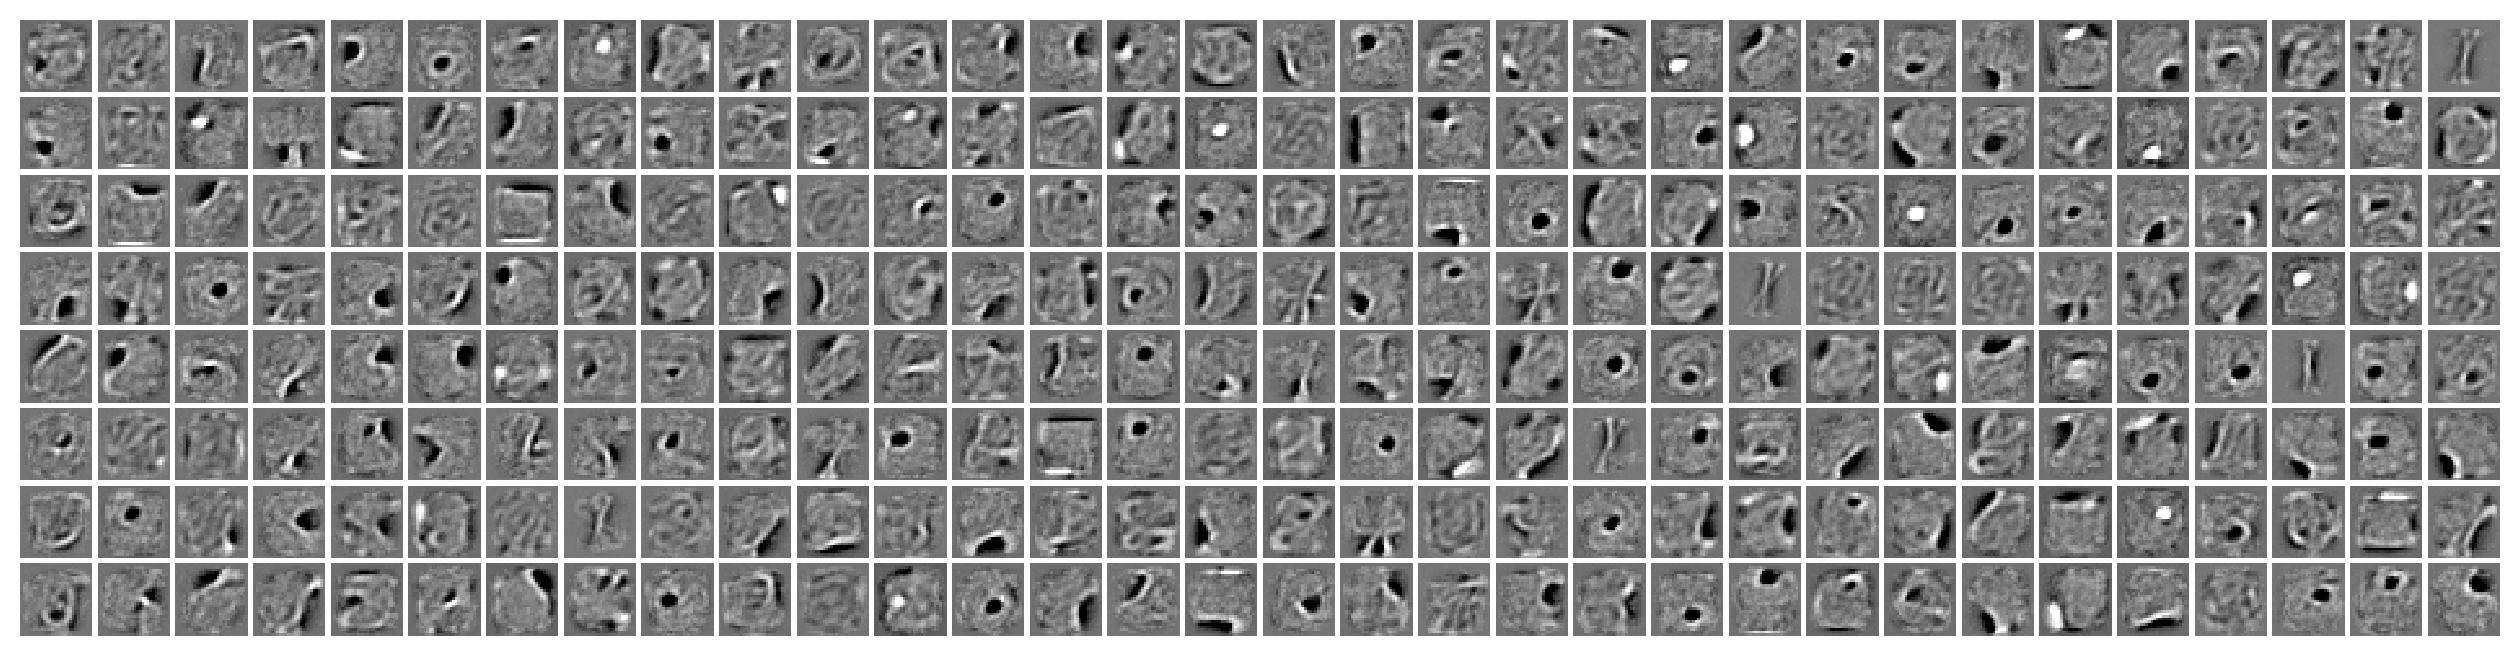

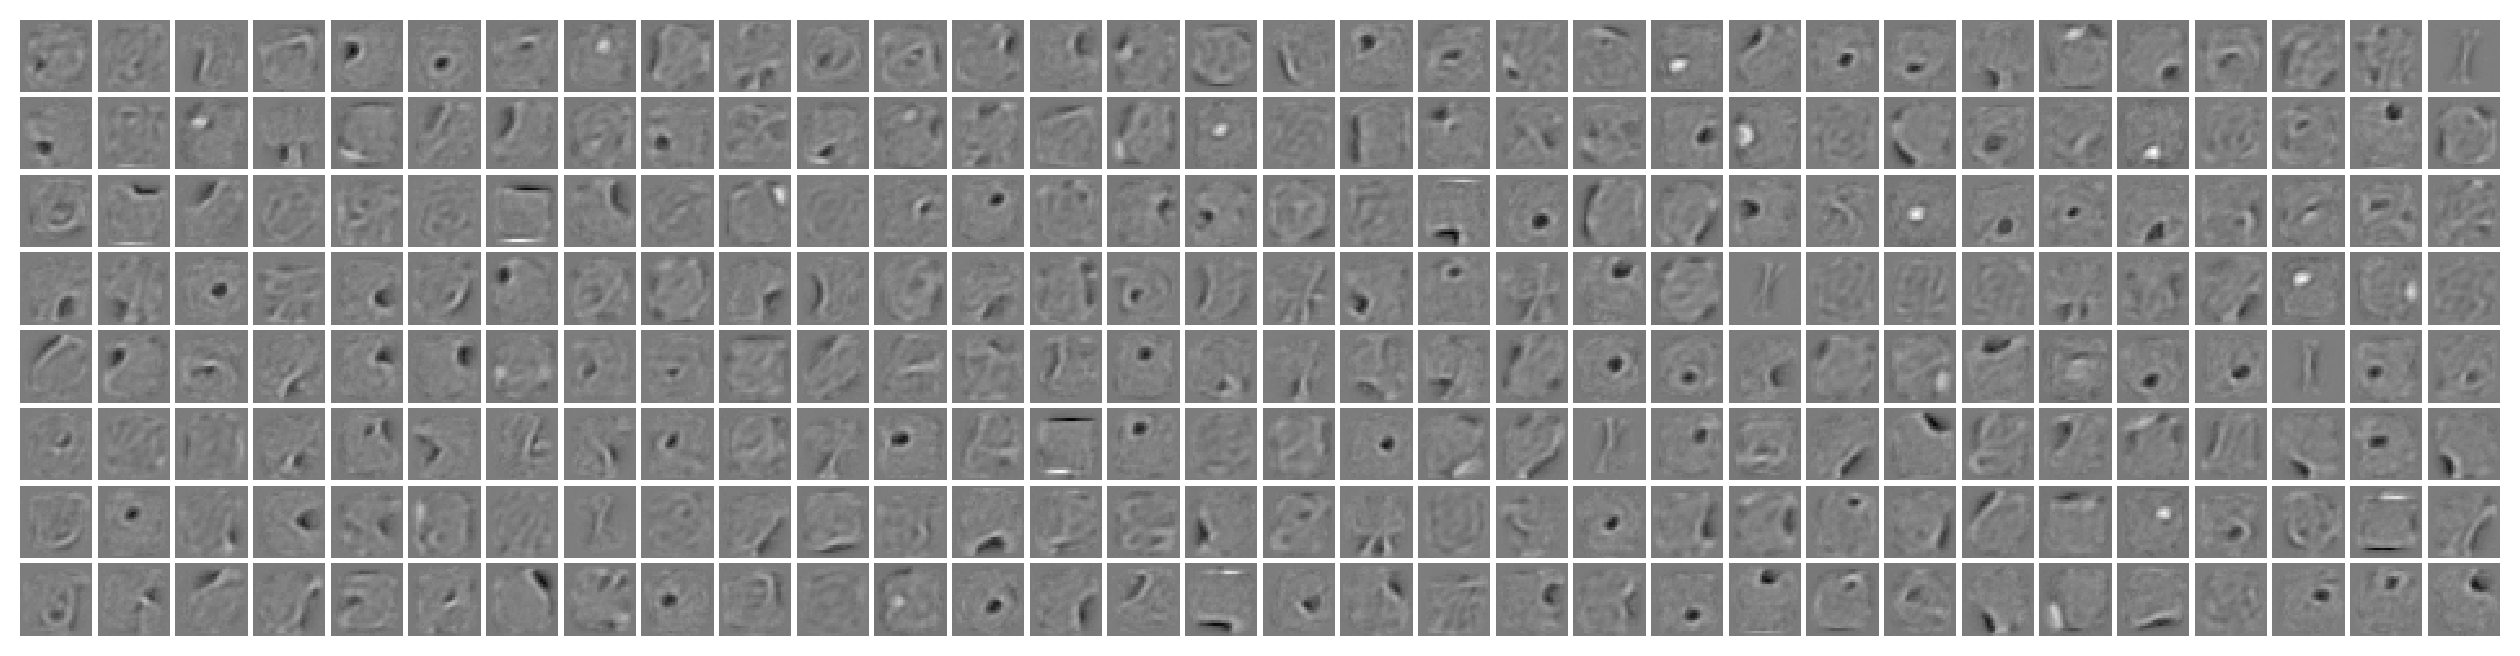

In [94]:
shallow_mlp = [
    Layer(
        visible_size=VISIBLE_LAYER_SIZE,
        hidden_size=HIDDEN_LAYER_SIZE,
        activation_fun=sigmoid,
        d_activation_fun=sigmoid_derivative,
        learning_rate=LEARNING_RATE,
        momentum=MOMENTUM,
        l2_penalty=L2_PENALTY,
    ),
    Layer(
        visible_size=HIDDEN_LAYER_SIZE,
        hidden_size=HIDDEN_LAYER_SIZE,
        activation_fun=sigmoid,
        d_activation_fun=sigmoid_derivative,
        learning_rate=LEARNING_RATE,
        momentum=MOMENTUM,
        l2_penalty=L2_PENALTY,
    ),
    Layer(
        visible_size=HIDDEN_LAYER_SIZE,
        hidden_size=10,
        activation_fun=softmax,
        d_activation_fun=None,
        learning_rate=LEARNING_RATE,
        momentum=MOMENTUM,
        l2_penalty=L2_PENALTY,
    ),
]

shallow_dbn = [
    RestrictedBoltzmannMachine(
        visible_size=mlp_layer.visible_size,
        hidden_size=mlp_layer.hidden_size,
        learning_rate=LEARNING_RATE,
        momentum=MOMENTUM,
        l1_penalty=0.0,
        l2_penalty=L2_PENALTY,
    )
    for mlp_layer in shallow_mlp[:-1]
]

compare_pretraining_results(
    mlp=shallow_mlp,
    dbn=shallow_dbn,
    train_set=mnist_train_images,
    train_labels=mnist_train_labels,
    validation_set=mnist_test_images,
    validation_labels=mnist_test_labels,
    monitoring_set=monitoring_set,
    batch_size=BATCH_SIZE,
    epochs_count=EPOCHS_COUNT,
)

### Deep neural network

Epoch 1:	########################################	elapsed: 1.12s, accuracy: 8.92
Epoch 2:	########################################	elapsed: 0.98s, accuracy: 8.92
Epoch 3:	########################################	elapsed: 0.92s, accuracy: 8.92
Epoch 4:	########################################	elapsed: 0.91s, accuracy: 11.35
Epoch 5:	########################################	elapsed: 0.92s, accuracy: 11.35
Epoch 6:	########################################	elapsed: 0.96s, accuracy: 11.35
Epoch 7:	########################################	elapsed: 0.81s, accuracy: 11.35
Epoch 8:	########################################	elapsed: 1.53s, accuracy: 11.35
Epoch 9:	########################################	elapsed: 1.00s, accuracy: 11.35
Epoch 10:	########################################	elapsed: 1.13s, accuracy: 11.35
Epoch 11:	########################################	elapsed: 0.74s, accuracy: 11.35
Epoch 12:	########################################	elapsed: 2.48s, accuracy: 11.35
Epoch 13:	######

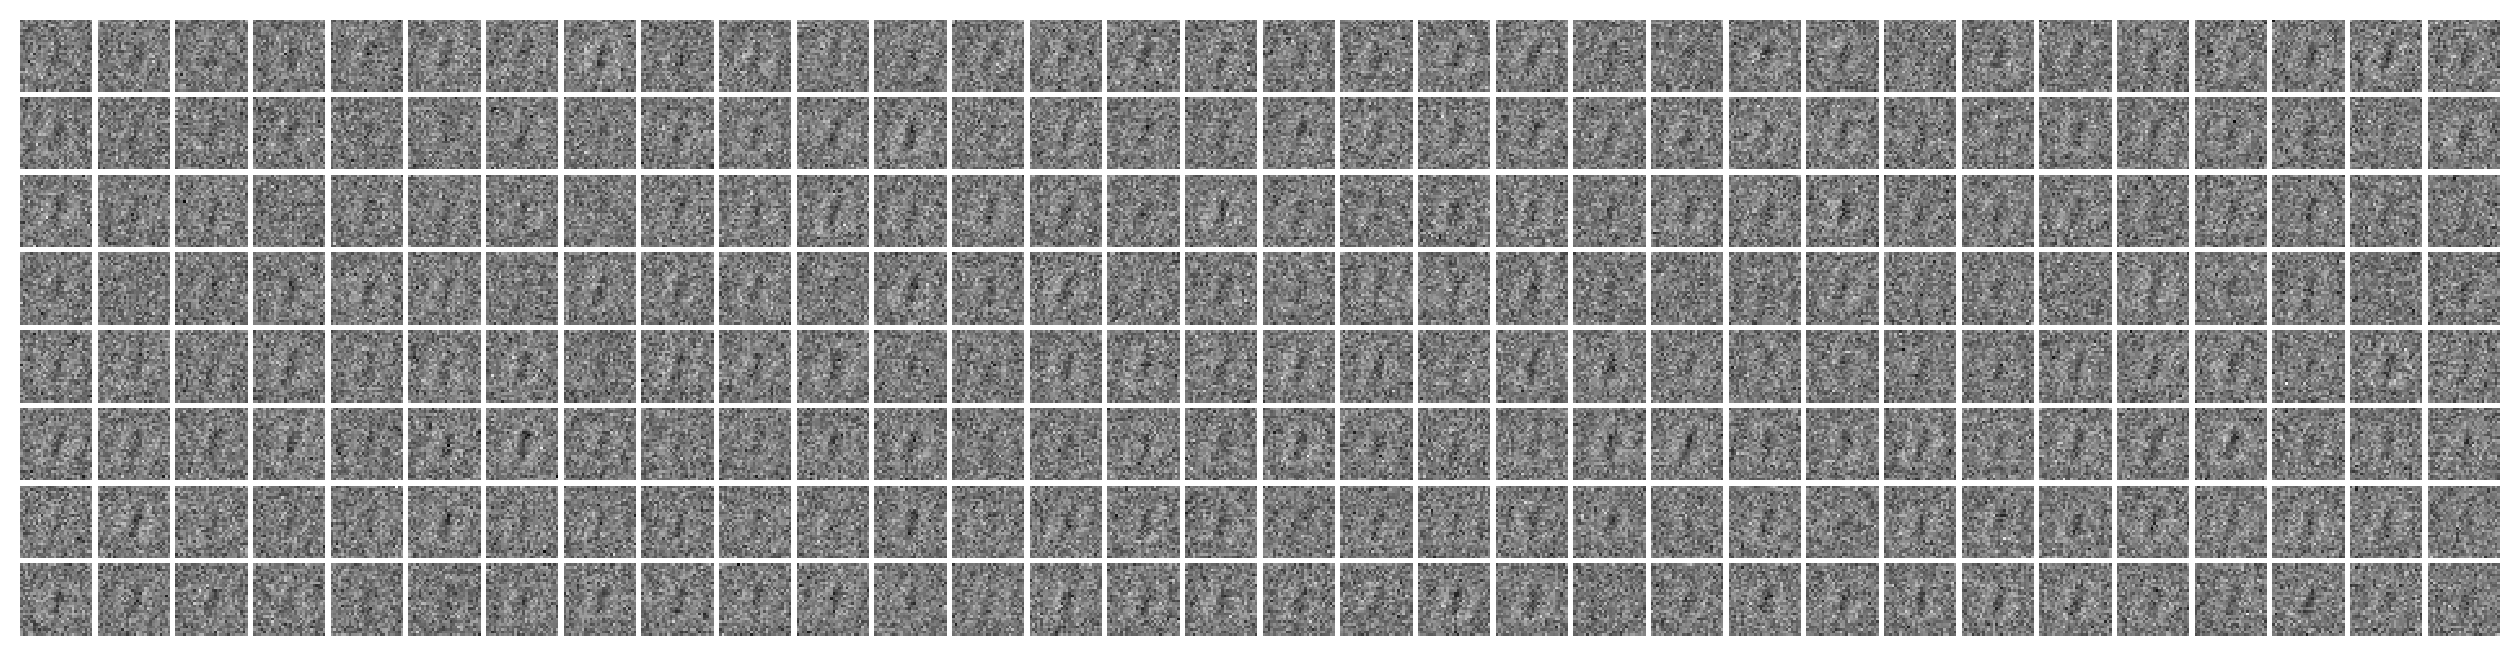


Learning layer 0
Epoch 0:	########################################	elapsed: 1.33s, reconstruction error: 0.00
Epoch 1:	########################################	elapsed: 1.24s, reconstruction error: 0.00
Epoch 2:	########################################	elapsed: 1.37s, reconstruction error: 0.00
Epoch 3:	########################################	elapsed: 1.38s, reconstruction error: 0.00
Epoch 4:	########################################	elapsed: 1.16s, reconstruction error: 0.00
Epoch 5:	########################################	elapsed: 1.20s, reconstruction error: 0.00
Epoch 6:	########################################	elapsed: 1.16s, reconstruction error: 0.00
Epoch 7:	########################################	elapsed: 1.28s, reconstruction error: 0.00
Epoch 8:	########################################	elapsed: 1.62s, reconstruction error: 0.00
Epoch 9:	########################################	elapsed: 1.13s, reconstruction error: 0.00
Epoch 10:	########################################	e

Epoch 1:	########################################	elapsed: 1.30s, accuracy: 90.96
Epoch 2:	########################################	elapsed: 0.85s, accuracy: 92.32
Epoch 3:	########################################	elapsed: 1.15s, accuracy: 93.00
Epoch 4:	########################################	elapsed: 0.85s, accuracy: 93.39
Epoch 5:	########################################	elapsed: 1.08s, accuracy: 93.69
Epoch 6:	########################################	elapsed: 0.83s, accuracy: 93.99
Epoch 7:	########################################	elapsed: 1.00s, accuracy: 94.21
Epoch 8:	########################################	elapsed: 0.91s, accuracy: 94.30
Epoch 9:	########################################	elapsed: 0.96s, accuracy: 94.42
Epoch 10:	########################################	elapsed: 0.86s, accuracy: 94.54
Epoch 11:	########################################	elapsed: 0.93s, accuracy: 94.64
Epoch 12:	########################################	elapsed: 1.32s, accuracy: 94.79
Epoch 13:	###

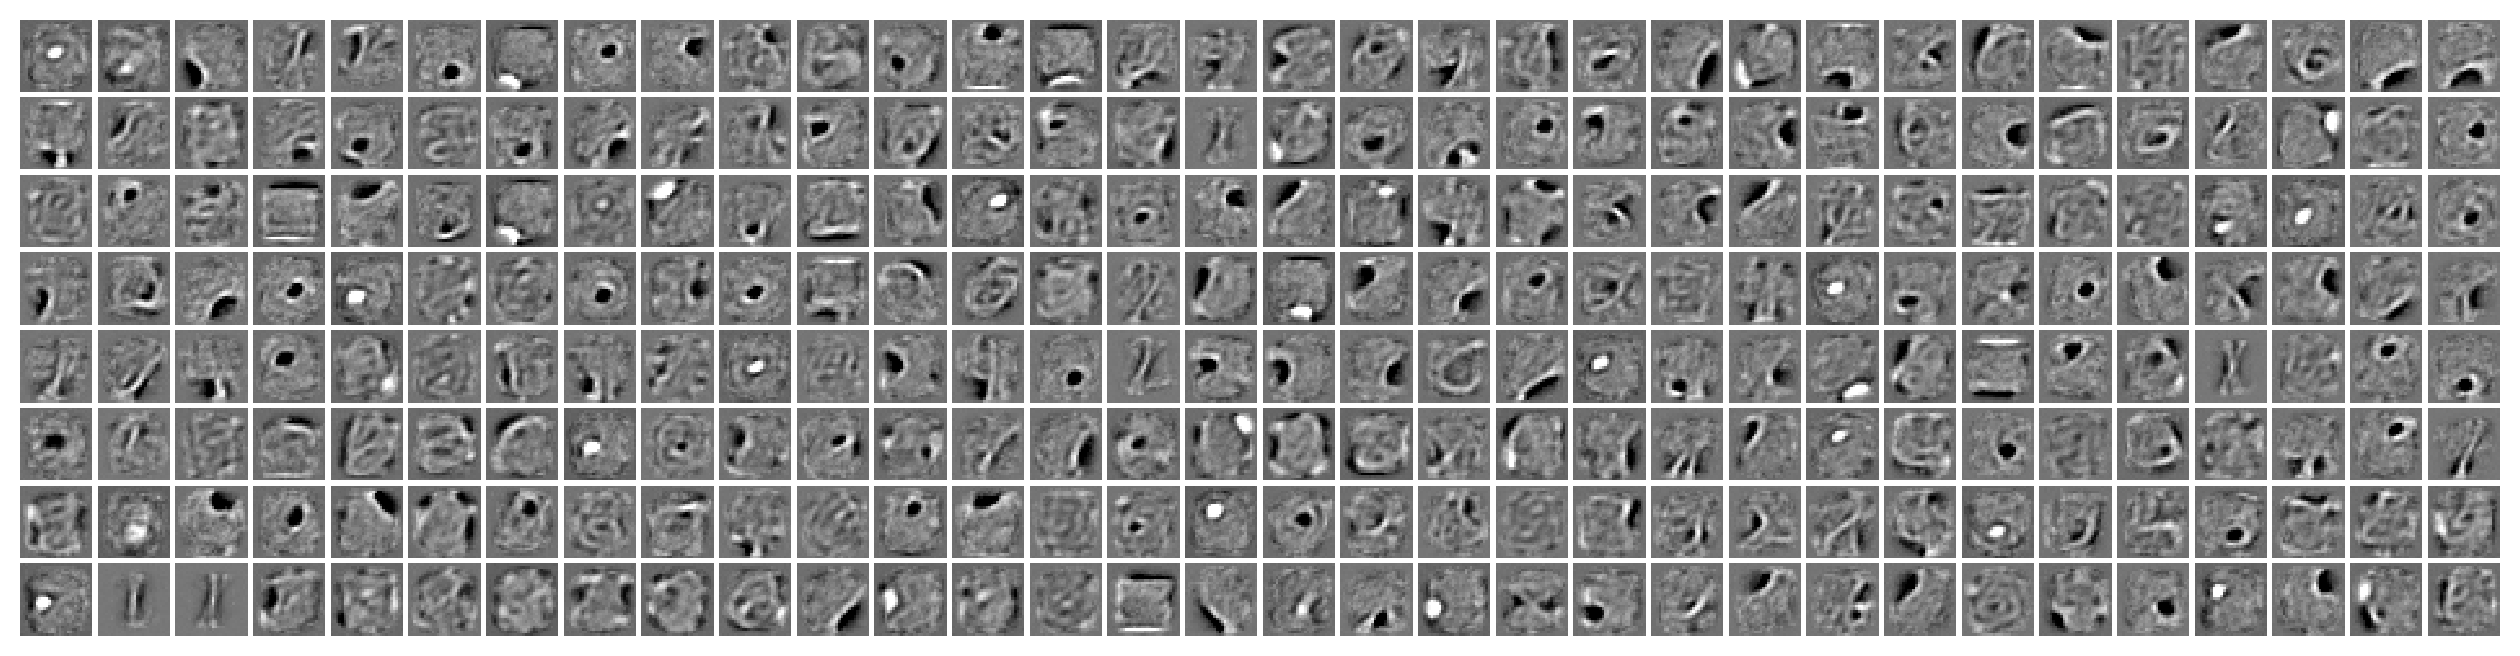

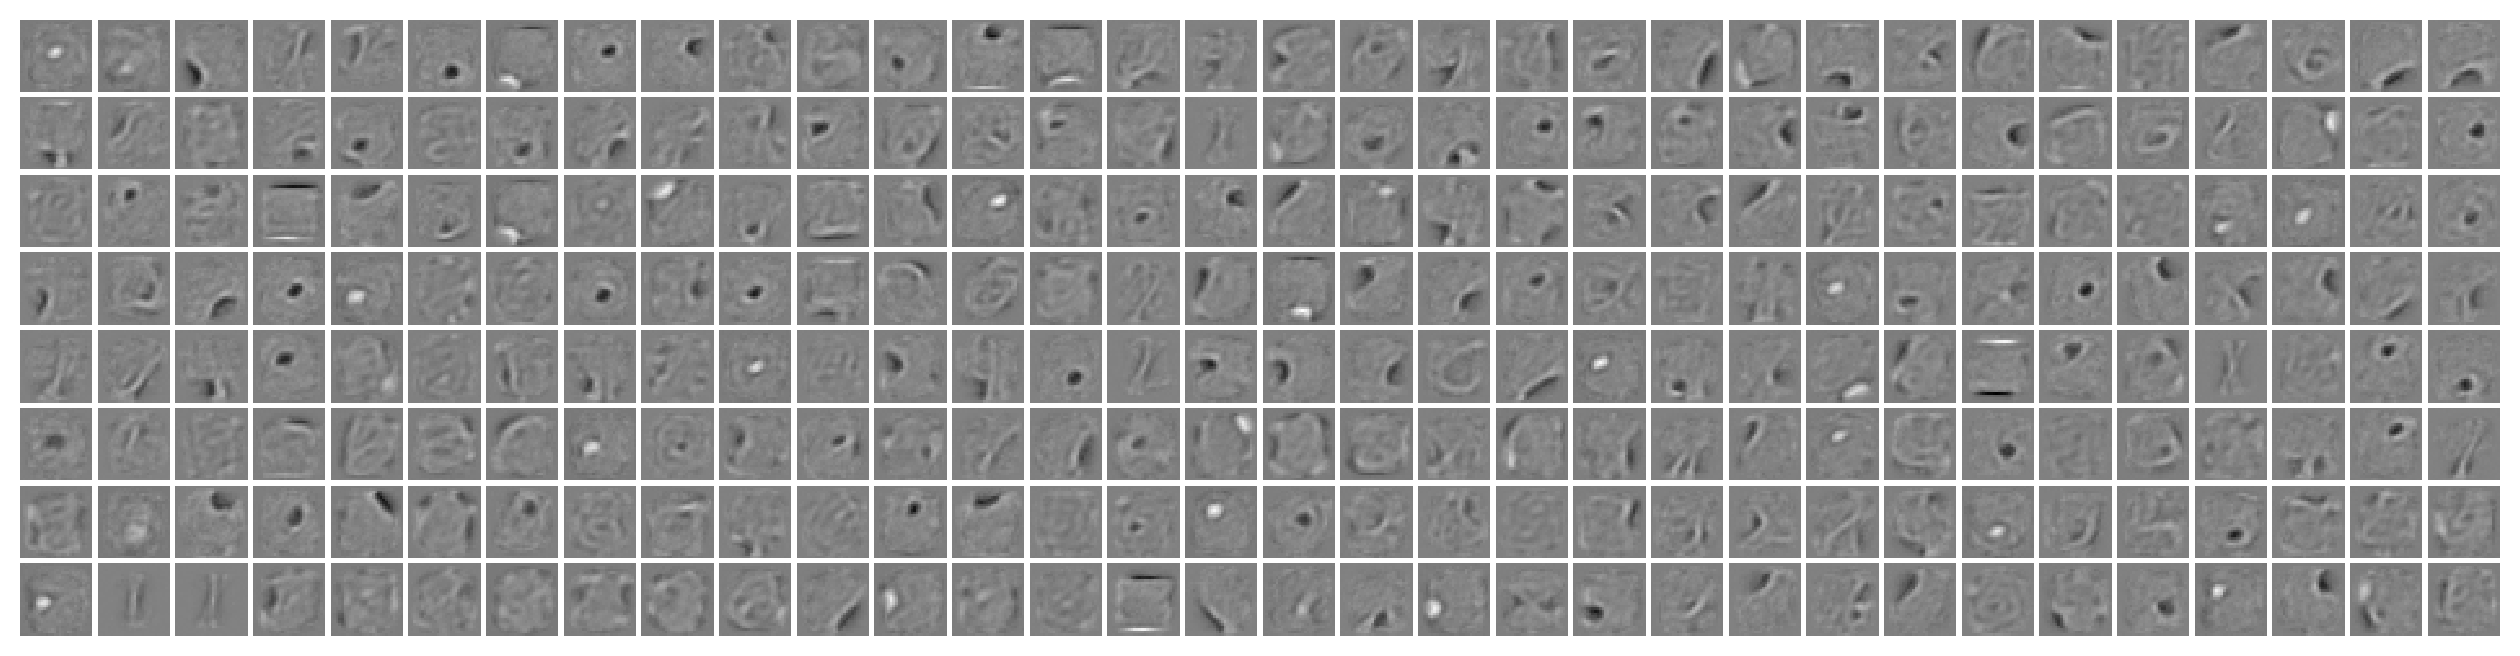

In [95]:
deep_mlp = [
    Layer(
        visible_size=VISIBLE_LAYER_SIZE,
        hidden_size=HIDDEN_LAYER_SIZE,
        activation_fun=sigmoid,
        d_activation_fun=sigmoid_derivative,
        learning_rate=LEARNING_RATE,
        momentum=MOMENTUM,
        l2_penalty=L2_PENALTY,
    ),
    Layer(
        visible_size=HIDDEN_LAYER_SIZE,
        hidden_size=HIDDEN_LAYER_SIZE,
        activation_fun=sigmoid,
        d_activation_fun=sigmoid_derivative,
        learning_rate=LEARNING_RATE,
        momentum=MOMENTUM,
        l2_penalty=L2_PENALTY,
    ),
    Layer(
        visible_size=HIDDEN_LAYER_SIZE,
        hidden_size=HIDDEN_LAYER_SIZE,
        activation_fun=sigmoid,
        d_activation_fun=sigmoid_derivative,
        learning_rate=LEARNING_RATE,
        momentum=MOMENTUM,
        l2_penalty=L2_PENALTY,
    ),
    Layer(
        visible_size=HIDDEN_LAYER_SIZE,
        hidden_size=10,
        activation_fun=softmax,
        d_activation_fun=None,
        learning_rate=LEARNING_RATE,
        momentum=MOMENTUM,
        l2_penalty=L2_PENALTY,
    ),
]

deep_dbn = [
    RestrictedBoltzmannMachine(
        visible_size=mlp_layer.visible_size,
        hidden_size=mlp_layer.hidden_size,
        learning_rate=LEARNING_RATE,
        momentum=MOMENTUM,
        l1_penalty=0.0,
        l2_penalty=L2_PENALTY,
    )
    for mlp_layer in deep_mlp[:-1]
]

compare_pretraining_results(
    mlp=deep_mlp,
    dbn=deep_dbn,
    train_set=mnist_train_images,
    train_labels=mnist_train_labels,
    validation_set=mnist_test_images,
    validation_labels=mnist_test_labels,
    monitoring_set=monitoring_set,
    batch_size=BATCH_SIZE,
    epochs_count=EPOCHS_COUNT,
)

## Additional materials
* [YT Steve Brunton - Sparsity and the L1 Norm](https://www.youtube.com/watch?v=76B5cMEZA4Y)
* [YT StatQuest - Ridge vs Lasso Regression, Visualized!!!](https://www.youtube.com/watch?v=Xm2C_gTAl8c)
* [YT DataMListic - L1 vs L2 Regularization](https://www.youtube.com/watch?v=aBgMRXSqd04)